# Step 1: Import necessary components

In [1]:
import torch
from sionna.phy import Block
from sionna.phy import config
from sionna.phy.channel import cir_to_time_channel, time_lag_discrete_time_channel, ApplyTimeChannel
from sionna.phy.channel.tr38901 import TDL
from sionna.phy.utils import ebnodb2no
from sionna.phy.mapping import BinarySource, Mapper, Demapper
from OTFS.ddgrid import DDGrid
from OTFS.transceiver import OTFSModulator, OTFSDemodulator
from OTFS.utils import release, generate_hdd_from_ht
from OTFS.equalizer import lmmse_equalizer_cg
device = "cuda:0"
config.device = device

# Step 2: Define Parameters and Components
- M: Number of delay bins / subcarriers

- N: Number of Doppler bins / OFDM symbols

- Q: Number of bits per data symbols
- batch_size: number of blocks sent in parallel in a Monte-Carlo simulation

In [2]:
batch_size = 10
M = 128 # Delay Bins
N = 14 # Doppler Bins
Q = 2 # Num bits per symbol
n = M * N * Q # Num bits a grid can carry
binary_source = BinarySource()
mapper = Mapper(constellation_type="qam", num_bits_per_symbol=Q)
demapper = Demapper(demapping_method="app", constellation_type="qam", num_bits_per_symbol=Q, hard_out=True)
# Shape [batch_size, num_bits]
bits = binary_source([batch_size, n])
symbols = mapper(bits)
print(f"Symbols ([batch_size, num_symbols]): {symbols.shape}")

Symbols ([batch_size, num_symbols]): torch.Size([10, 1792])


# Step 3: Collect data symbols into a DD grid

DD_grid ([batch_size, doppler_bins, delay_bins]): torch.Size([10, 14, 128])


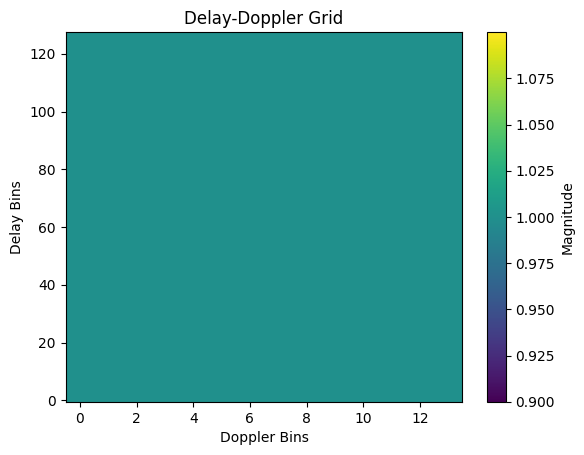

In [3]:
dd_grid = DDGrid(delay_bins=M, doppler_bins=N)
grid = dd_grid.collect(symbols)
print(f"DD_grid ([batch_size, doppler_bins, delay_bins]): {grid.shape}")
dd_grid.show()

# Benefit 1: Full diversity
We will put one test data symbol onto one lattice in the DD domain and use ISFFT to transform it into the TF domain. By doing so, we can observe that a symbol in the DD domain, after being ISFFTed to the TF domain, will spread its energy out across the whole TF domain. Thus, if there is a deepfade happening at some subcarriers in some (OFDM) symbols, the symbol in the DD domain only loses some of its energy instead of losing the whole symbol as in the case of OFDM.

In [4]:
s_test = torch.zeros((10, 1, 1, 1792), dtype=torch.complex64)
s_test[..., 1792//2] = 1 + 1j
grid_test = DDGrid(128, 14)
test_grid = grid_test.collect(s_test)
def isfft(grid):
    grid_DF = torch.fft.fft(grid, dim=4, norm="ortho") # FFT Delay
    grid_TF = torch.fft.ifft(grid_DF, dim=3, norm="ortho") # IFFT Doppler
    return grid_TF
grid_time_test = isfft(test_grid)
dd_energy = test_grid.abs()**2
tf_energy = grid_time_test.abs()**2
print("Check energy conservation")
print(dd_energy.sum(dim=(3,4))[0])
print(tf_energy.sum(dim=(3,4))[0])

Check energy conservation
tensor([[2.0000]])
tensor([[2.0000]])


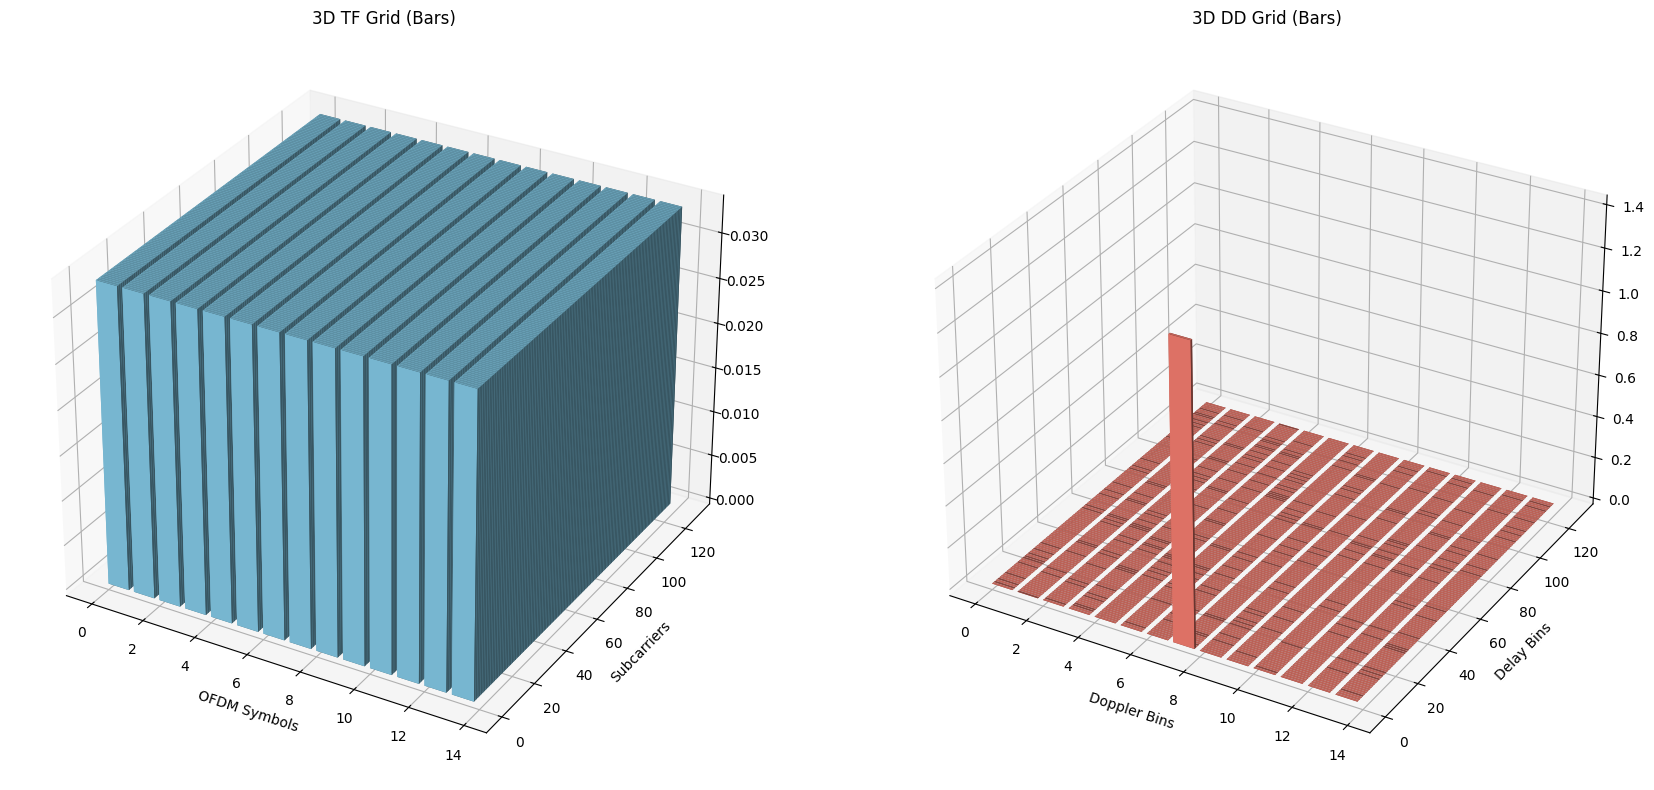

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare Magnitude Data (first batch element)
# Take magnitude and move to CPU [cite: 168, 169, 172]
tf_mag = grid_time_test.abs()[0].squeeze().cpu().detach().numpy()
dd_mag = test_grid.abs()[0].squeeze().cpu().detach().numpy()

# 2. Define the Grid Coordinates [cite: 200, 204]
n_bins, m_bins = tf_mag.shape # 14 and 128
_x = np.arange(n_bins)
_y = np.arange(m_bins)
_xx, _yy = np.meshgrid(_x, _y, indexing='ij')

# 3. Flatten coordinates for ax.bar3d
x, y = _xx.ravel(), _yy.ravel()
top_tf = tf_mag.ravel()
top_dd = dd_mag.ravel()

# Bottom of bars starts at zero [cite: 180]
bottom = np.zeros_like(top_tf)
width = depth = 0.8 # Bar width/depth (less than 1 to create gaps)

# 4. Initialize 3D Figure
fig = plt.figure(figsize=(18, 8))

# --- Subplot 1: Time-Frequency Bars ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.bar3d(x, y, bottom, width, depth, top_tf, shade=True, color='skyblue')
ax1.set_title('3D TF Grid (Bars)')
ax1.set_xlabel('OFDM Symbols')
ax1.set_ylabel('Subcarriers')

# --- Subplot 2: Delay-Doppler Bars ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.bar3d(x, y, bottom, width, depth, top_dd, shade=True, color='salmon')
ax2.set_title('3D DD Grid (Bars)')
ax2.set_xlabel('Doppler Bins')
ax2.set_ylabel('Delay Bins')

plt.tight_layout()
plt.show()

# Step 4: OTFS Modulator
The OTFS modulator consists of an ISFFT, defined as

$$X[n, m] = \frac{1}{\sqrt{NM}} \sum_{k=0}^{N-1} \sum_{l=0}^{M-1} x[k, l] e^{j2\pi \left( \frac{nk}{N} - \frac{ml}{M} \right)}$$

The term Symplectic refers to the pairing of the transform (note that the logic is inverse that of traditional DFT):
1. Doppler ($k$) $\to$ Time ($n$): Uses a IFFT.
2. Delay ($l$) $\to$ Frequency ($m$): Uses an FFT.

The TF grid then undergoes the Heisenberg Transform, defined as

$$s(t) = \sum_{n=0}^{N-1} \sum_{m=0}^{M-1} X[n, m] g_{tx}(t - nT) e^{j2\pi m\Delta f (t - nT)}$$

$T$: Symbol duration (time shift).

$\Delta f$: Subcarrier spacing (frequency shift).

$g_{tx}(t)$: The transmit pulse shape.

It can be observed that OFDM is Heisenberg Transform with Rect pulse shape, and we can use different pulse shape for reduce OOB or for other purposes.

After getting the Time-Domain signal, we append a Cyclic Prefix to the beginning of the OTFS waveform. For?

In [6]:
L = 30 # CP Length added to one M*N OTFS frame
otfs_modulator = OTFSModulator(cyclic_prefix_length=L)
signal = otfs_modulator(grid)
print(f"Signal shape ([batch_size, num_time_samples]): {signal.shape}")
print("Check energy:")
dd_energy = grid.abs()**2
signal_energy = signal.abs()**2
cp_energy = signal_energy[..., -30:]
print(f"DD Grid Energy: {dd_energy.sum(dim=(1,2))[0] + cp_energy.sum(dim=(-1))[0]}")
print(f"Time-Domain Signal Energy: {signal_energy.sum(dim=(-1))[0]}")

Signal shape ([batch_size, num_time_samples]): torch.Size([10, 1822])
Check energy:
DD Grid Energy: 1812.641845703125
Time-Domain Signal Energy: 1812.64111328125


# Step 5: Generate the Time Channel

We use TDL-C with 300ns nominal delay spead in 100 m/s mobility. The frequency shift (subcarrier spacing) of the Heisenberb Transform is 15kHz. The time shift (symbol duration) is calculated accordingly to maintain lattice constraint ($\Delta f \times T = 1$)

In [7]:
ebno_db = 2.5 # Test
no = ebnodb2no(ebno_db=ebno_db, num_bits_per_symbol=2, coderate=1.0)
tdl = TDL(model="C", delay_spread=300e-9, carrier_frequency=4e9, min_speed=100)
l_min, l_max = time_lag_discrete_time_channel(bandwidth=128*15000)
l_tot = l_max - l_min + 1
a, tau = tdl(batch_size=batch_size, num_time_steps=signal.shape[-1]+l_tot-1, sampling_frequency=128 *15000)
h_t = cir_to_time_channel(bandwidth=128*15000, a=a, tau=tau, l_min=l_min, l_max=l_max, normalize=True)
apply_channel = ApplyTimeChannel(num_time_samples=signal.shape[-1], l_tot = l_tot)
received_signal= apply_channel(signal.unsqueeze(1).unsqueeze(1), h_t, no)
h_t = h_t.squeeze()
received_signal = received_signal.squeeze()
print(f"Received Signal ([batch_size, num_time_samples]): {received_signal.shape}")
print(f"Time-Domain CIR ([batch_size, num_time_samples, num_delay_taps]): {h_t.shape}") # 1840 Time samples, 19 delay taps

Received Signal ([batch_size, num_time_samples]): torch.Size([10, 1840])
Time-Domain CIR ([batch_size, num_time_samples, num_delay_taps]): torch.Size([10, 1840, 19])


# Step 7: Apply the channel on the Signal

$$r[n] = \sum_{l=0}^{L-1} h[n, l] s[n - l] + w[n]$$

$l$: The Delay Tap index.

$n$: The Time index.

$h[n, l]$: The complex channel coefficient for the $l$-th tap at time $n$.

$w[n]$: AWGN.


# Step 8: Set up the demodulator and check if the demodulator correctly recovers data symbols in the absence of the channel

## Step up the demodulator

aaaaaa

In [8]:
otfs_demodulator = OTFSDemodulator(M, N, L)

## Check ...

In [9]:
check_grid = otfs_demodulator(signal)
print(f"Received grid: {check_grid.shape}" )
check_symbols = release(check_grid)
print(f"Received symbols: {check_symbols.shape}" )
check_bits = demapper(check_symbols, no)
print(f"Received bits: {check_bits.shape}" )
compare = bits == check_bits
ber = 1.0 - torch.mean(compare.float())
print(f"BER: {ber}") # Should be zero

Received grid: torch.Size([10, 14, 128])
Received symbols: torch.Size([10, 1792])
Received bits: torch.Size([10, 3584])
BER: 0.0


# Step 9: Demodulate the Time-Domain signal to the DD domain Grid symbol vector

In [10]:
# Now in the presence of channel, we need to perform equalization on the received symbols
received_grid = otfs_demodulator(received_signal)
received_symbols = release(received_grid)
print(f"Received symbols: {received_symbols.shape}" )

Received symbols: torch.Size([10, 1792])


# Step 10: Derive the In-Out Relationship in the DD domain

Hard

## Brute-Force

Since the in-out relationship in the DD domain is linear, i.e.
        $$\mathbf{y}_{DD} = \mathbf{H}_{DD} \mathbf{x}_{DD}$$

(assume no noise)

We can calculate the matrix $\mathbf{H}_{DD}$ by using the property that
                $$\mathbf{H}_{DD} \mathbf{e}_j = \mathbf{h}_j$$
where $\mathbf{h}_j$ is the $j$-th column of $\mathbf{H}_{DD}$

Therefore, we can construct the channel matrix by transmiting probe basis vectors over the time channel defined by Sionna and collect the received symbol vectors as columns of the channel matrix. This cheating way requires no careful inspection of the channel physics and is only used for verification and testing.

In [11]:
def generate_hdd_from_tdl_brute_force(
    h_t,
    delay_bins,
    doppler_bins,
    basis_batch=64,
):
    """
    probe the H_DD by sending basis vectors

    Input
    ----------
    h_t : torch.Tensor
        [batch_size, num_time_samples, num_delay_taps]
    delay_bins : int
        M
    doppler_bins : int
        N
    basis_batch : int
        Number of DD basis vectors to probe at once

    Output
    -------
    h_dd : torch.Tensor
        Shape [B, NM, NM]
    """
    if h_t.ndim != 3:
        raise ValueError(
            f"h_t must have shape [batch_size, num_time_samples, num_delay_taps], got {tuple(h_t.shape)}"
        )

    device = h_t.device
    dtype = h_t.dtype
    batch_size, num_time_samples, num_delay_taps = h_t.shape

    M = delay_bins
    N = doppler_bins
    frame_size = M * N

    h_dd = torch.zeros(
        (batch_size, 1, 1, frame_size, frame_size),
        dtype=dtype,
        device=device,
    )

    eye = torch.eye(frame_size, dtype=dtype, device=device)

    for b in range(batch_size):
        # [1, T, L]
        h_t_b = h_t[b:b+1]

        for start in range(0, frame_size, basis_batch):
            stop = min(start + basis_batch, frame_size)
            num_basis = stop - start

            # Basis vectors in PAPER ordering: j = k*M + l
            basis_symbols = eye[start:stop]                         # [num_basis, NM]
            basis_grid = basis_symbols.reshape(num_basis, N, M)     # [num_basis, N, M]
            basis_grid = basis_grid.unsqueeze(1).unsqueeze(1).contiguous()  # [num_basis,1,1,N,M]

            # Modulate each basis vector
            tx = otfs_modulator(basis_grid)  # [num_basis,1,1, tx_len]

            # Repeat the same channel realization for all probed basis vectors
            h_t_rep = h_t_b.expand(num_basis, num_time_samples, num_delay_taps).contiguous()

            # Apply channel
            rx = apply_channel(tx, h_t_rep, None)

            # Demodulate and release back to vector form
            rx_grid = otfs_demodulator(rx)                    # [num_basis,1,1,N,M]
            rx_symbols = release(rx_grid)                     # [num_basis,1,1,NM]
            rx_symbols = rx_symbols.squeeze(1).squeeze(1)     # [num_basis, NM]

            # Each received vector is one column of H_DD
            h_dd[b, 0, 0, :, start:stop] = rx_symbols.transpose(0, 1)

    return h_dd.squeeze()

## Derive $H_{DD}$

If the transmitted signal is

$$s=\begin{bmatrix}s[0]&s[1]&\cdots&s[NM-1]\end{bmatrix}^T$$

before adding the CP

and the received signal is

$$y[q]=r[q+L_{\text{cp}}], \qquad q=0,\dots,NM-1,$$

after removing the CP.

Then $y = H_T s$, where

$$[H_T]_{q,p}
=
\begin{cases}
h[q+L_{\text{cp}},\, q-p], & 0 \le q-p \le L_h-1 \\[0.8ex]
h[q+L_{\text{cp}},\, q-p+NM], & -L_{\text{cp}} \le q-p < 0 \\[0.8ex]
0, & \text{otherwise}
\end{cases}$$

We can observe that $H_T$, if LTV, is circular but time-varying row-by-row, not circulant as in OFDM LTI case.

Nevertheless, we do not need to build the $H_T$ using the above structure.

Denote: $s \in \mathbb{C}^{NM}$ be the transmit time-domain vector before CP. Then the CP-added version is $x_{\text{cp}} = C s,$ where $C$ is the CP matrix. So, STEP 1: Build the CP matrix/

The time-domain channel model is
$$r[n] = \sum_{\ell=0}^{L_h-1} h[n,\ell]\,x_{\text{cp}}[n-\ell]$$

this can be written as $r = H_{\text{full}} x_{\text{cp}},$ where $$[H_{\text{full}}]_{n,m} =
\begin{cases}
h[n,\,n-m], & 0 \le n-m \le L_h-1\\
0, & \text{otherwise.}
\end{cases}$$

After removing the CP, the effective time sample in the channel matrix ranges from $L_cp$ to $L_cp + MN -1$. The effective $H_T$ is then

$$H_T = R H_{\text{full}} C$$

where $R$ is a matrix such that $R H_{\text{full}} = H_{\text{full}}[L_{\text{cp}}:L_{\text{cp}} + MN]$.

After that, $H_DD$ can be derived as

$$H_{DD} = (F_N \otimes I_M)\,H_T\,(F_N^H \otimes I_M). \tag{[1]}$$

It is noted that this model is for non-fractional Doppler/Delay (i.e. the Doppler/Delay resolution is thin enough to sample all existing delay/doppler values)

In [12]:
H_DD = generate_hdd_from_ht(h_t=h_t, M=M, N=N, cp_len=L)
print(f"H_DD shape [batch_size, num_symbols, num_symbols] {H_DD.shape}")

H_DD shape [batch_size, num_symbols, num_symbols] torch.Size([10, 1792, 1792])


# Benefit 2: Sparsity

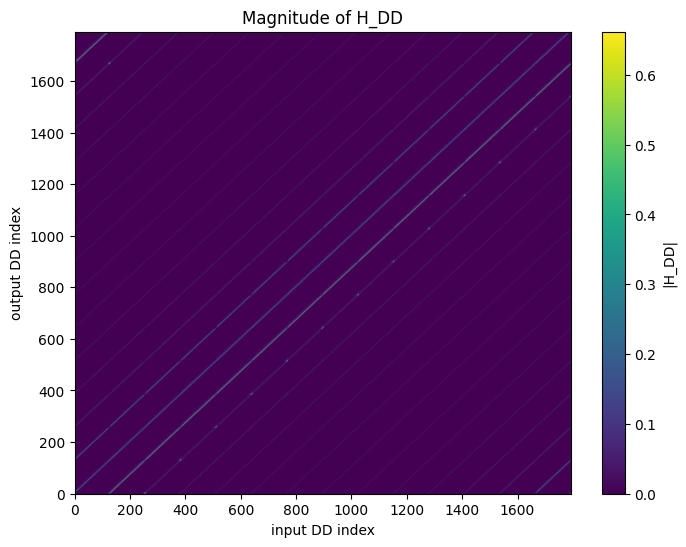

In [13]:
import matplotlib.pyplot as plt

H = H_DD[0]
H_abs = H.abs().detach().cpu().numpy()

plt.figure(figsize=(8, 6))
plt.imshow(H_abs, aspect="auto", origin="lower")
plt.colorbar(label="|H_DD|")
plt.title("Magnitude of H_DD")
plt.xlabel("input DD index")
plt.ylabel("output DD index")
plt.show()

# Step 11: Equalization

## LMMSE Equalization

Since the in-out relationship in the DD domain is linear, i.e.

$$\mathbf{y}_{DD} = \mathbf{H}_{DD} \mathbf{x}_{DD} + \mathbf{w}$$

a natural choice for estimating $\mathbf{x}_{DD}$ is the LMMSE estimator. The LMMSE estimator has the form

$$\hat{\mathbf{x}}=\mathbf{W}\mathbf{y}$$

where


$$\mathbf{W}
=
\left(\mathbf{H}^H\mathbf{H}+n_0\mathbf{I}\right)^{-1}\mathbf{H}^H$$

solving this would cost $O((NM)^3)$.

Conjugate Gradient can be used to solve for $\hat{\mathbf{x}}$ in this Linear Equation

$$\mathbf{A}\hat{\mathbf{x}} = \mathbf{H}^H\mathbf{y}$$

where $\mathbf{A} = \mathbf{H}^H\mathbf{H}+n_0\mathbf{I}$ is Hermitian and positive definite. The sparsity is not used here.

Sparse Matrix solver, such as Sparse Cholesky or Sparse $LDL^H$ can also be used.

## Post-Equalization Error Variance
The equalized symbol $\hat{x_i}$ can be modeled as

$$\hat{x}_i \approx x_i + \eta_i$$

The variance of $\eta_i$ is the diagonal entries of this covariance matrix

$$\mathbf{C}_e=n_0(\mathbf{H}_{DD}^H\mathbf{H}_{DD}+n_0\mathbf{I})^{-1}$$

where Hutchinson diagonal estimator can be used.

Details can be found at https://nvlabs.github.io/sionna/phy/api/mimo/sionna.phy.mimo.lmmse_equalizer.html

This LMMSE is not optimal and still requires extensive computation. Other equalizers, such as DI-S-LMMSE or Cross Domain Iterative Detection that utilize the sparsity will be implemented in further simulations.

In [14]:
# H_brute = generate_hdd_from_tdl_brute_force(h_t, M, N, 64)
equalized_symbols, no_eff = lmmse_equalizer_cg(received_symbols, H_DD, no)
received_bits = demapper(equalized_symbols, no_eff)

compare = received_bits == bits
err = 1 - torch.mean(compare.float())
print("BER:", err.item())

BER: 0.0750836730003357


# Step 12: End2End Models for BER evaluations

Running OFDM, static, 0.0 m/s
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 1.3229e-01 | 1.0000e+00 |      436825 |     3302000 |         1000 |        1000 |         0.6 |reached target block errors
      2.0 | 8.7124e-02 | 1.0000e+00 |      287685 |     3302000 |         1000 |        1000 |         0.6 |reached target block errors
      4.0 | 5.6189e-02 | 1.0000e+00 |      185537 |     3302000 |         1000 |        1000 |         0.5 |reached target block errors
      6.0 | 3.1969e-02 | 1.0000e+00 |      105560 |     3302000 |         1000 |        1000 |         0.5 |reached target block errors
      8.0 | 1.7910e-02 | 9.9804e-01 |       60323 |     3368040 |         1018 |        1020 |         0.5 |reached target block errors
     10.0 | 1.0405e-02 | 9.5660e-01

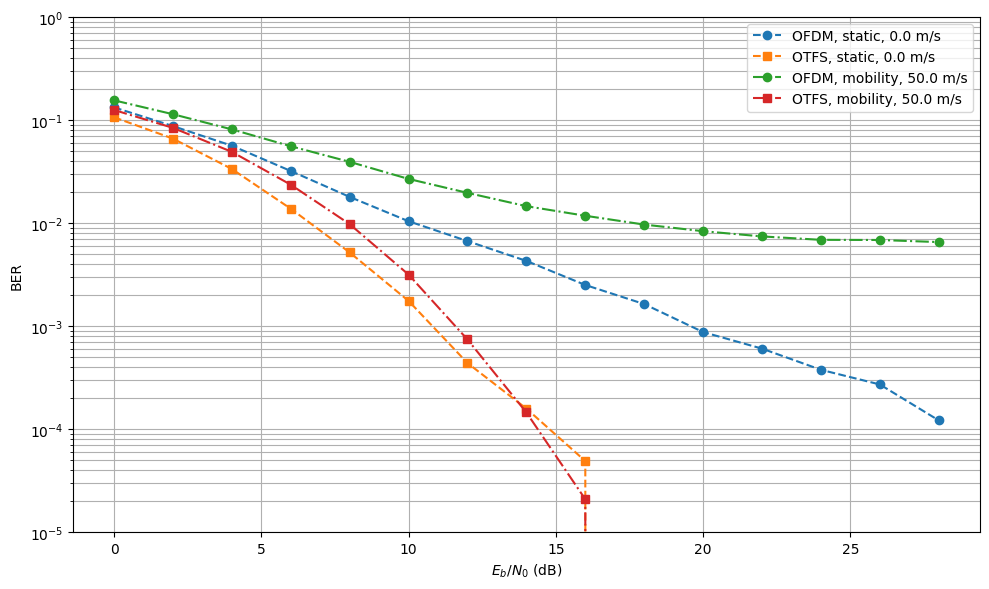

In [15]:
from OTFS.comparision import main
results = main()
# Save the simulation results
# np.save("results.npy", results)

In [18]:
data = np.load("results.npy", allow_pickle=True).item()

# References

[1] H. Li and Q. Yu, "Doubly-Iterative Sparsified MMSE Turbo Equalization for OTFS Modulation," 2024. [Online]. Available: https://arxiv.org/abs/2207.00866

[2] R. Hadani et al., "Orthogonal Time Frequency Space Modulation," arXiv:1808.00519, 2018. [Online]. Available: https://arxiv.org/abs/1808.00519